<img src="Python_logo.svg" alt="Python Logo" style="display: block; margin-left: auto; margin-right: auto;" width="100">

<div align='center'><font size='10'> Modeling Returns </font></div>

# Table of Contents

* [1 Import Libraries](#1-Import-Libraries)
* [2 Load GBP/USD Data](#2-Load-GBP-USD-Data)
* [3 Calculate return](#3-Calculate-return)
* [4 Calculate Mean & Sigma](#4-Calculate-Mean-Sigma)
* [5 Calculate Scaled Returns](#5-Calculate-Scaled-Returns)
* [6 Calculate Bin Range](#6-Calculate-Bin-Range)
* [7 References](#7-References)

# Normal Distribution

Normal Distribution, also known as Gaussian distribution is one of the most widely assumed distribution in Data Science. A normal distribution has a bell-shaped density curve described by its mean $\mu$ and standard deviation $\sigma$. The density curve is symmetrical, centered about its mean, with its spread determined by its standard deviation.

The probability distribution function of a normal density curve with mean $\mu$ and standard deviation $\sigma$ at a given point x is given by:
$$ \color{crimson}{ f(x\space|\space\mu,\sigma^2)=\frac1{\sqrt{2\pi\sigma^2}} \ e^\frac{-(x-\mu)^2}{2\sigma^2} } $$

## 1 Import Libraries <a id="1-Import-Libraries"></a>

We'll import the required libraries that we'll use in this example.

In [1]:
# Import Pandas, Numpy 
import pandas as pd
import numpy as np

# Import matplotlib for visualization
import matplotlib
import matplotlib.pyplot as plt

# Plot settings
# plt.style.available
plt.style.use('ggplot')
matplotlib.rcParams['figure.figsize'] = [12.0, 8.0]
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['lines.linewidth'] = 2 

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 2 Load GBPUSD Data <a id="2-Load-GBP-USD-Data"></a>

In [2]:
# Load the CSV file
df = pd.read_csv('SP500.csv', index_col=0, parse_dates=True)['2011':'2023']
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2011-01-03,1257.619995,1276.170044,1257.619995,1271.869995,1271.869995,4286670000
2011-01-04,1272.949951,1274.119995,1262.660034,1270.199951,1270.199951,4796420000
2011-01-05,1268.780029,1277.630005,1265.359985,1276.560059,1276.560059,4764920000
2011-01-06,1276.290039,1278.170044,1270.430054,1273.849976,1273.849976,4844100000
2011-01-07,1274.410034,1276.829956,1261.699951,1271.500000,1271.500000,4963110000
...,...,...,...,...,...,...
2021-01-11,3803.139893,3817.860107,3789.020020,3799.610107,3799.610107,4450500000
2021-01-12,3801.620117,3810.780029,3776.510010,3801.189941,3801.189941,4977210000
2021-01-13,3802.229980,3820.959961,3791.500000,3809.840088,3809.840088,4590420000


Text(0.5, 1.0, 'SP 500: 2011 - 2023')

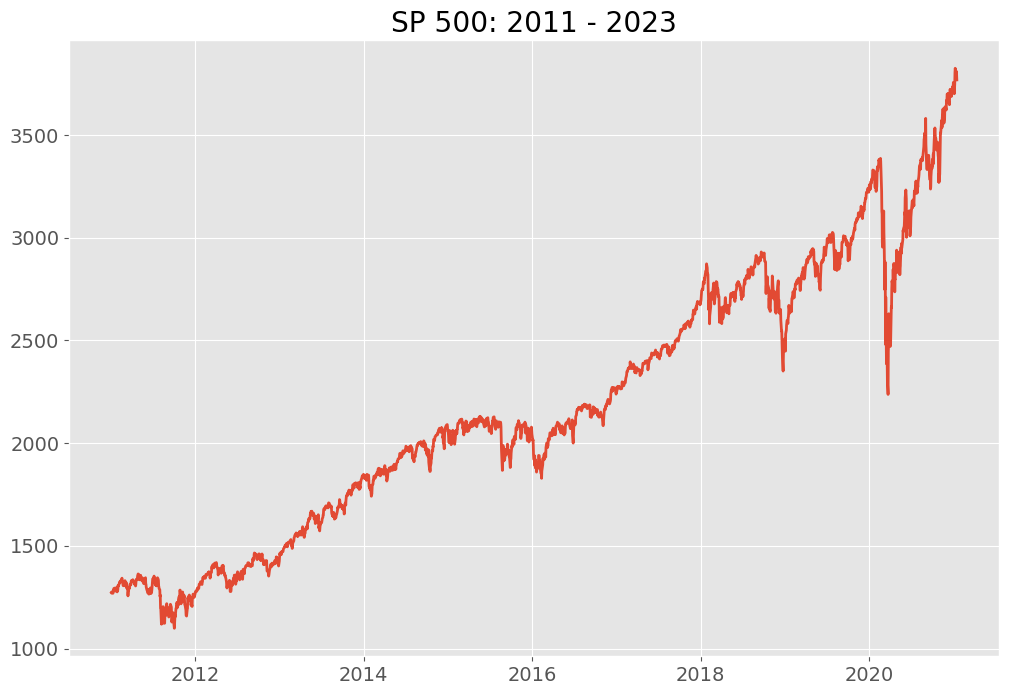

In [3]:
# Visualize the plot to verify the data
plt.plot(df['Adj Close'])
plt.title('SP 500: 2011 - 2023')

In [4]:
# Verify the datetime format
df.index

DatetimeIndex(['2011-01-03', '2011-01-04', '2011-01-05', '2011-01-06',
               '2011-01-07', '2011-01-10', '2011-01-11', '2011-01-12',
               '2011-01-13', '2011-01-14',
               ...
               '2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15'],
              dtype='datetime64[ns]', name='Date', length=2527, freq=None)

In [5]:
# get last 300 index values
df.index[-300:]

DatetimeIndex(['2019-11-07', '2019-11-08', '2019-11-11', '2019-11-12',
               '2019-11-13', '2019-11-14', '2019-11-15', '2019-11-18',
               '2019-11-19', '2019-11-20',
               ...
               '2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15'],
              dtype='datetime64[ns]', name='Date', length=300, freq=None)

## 3 Calculate return <a id="3-Calculate-return"></a>

In [6]:
# Calculate returns and add it to existing DataFrame as a column
df['Return'] = df['Adj Close'].pct_change().fillna(0)

# Get first 5 rows
df.head()

,Open,High,Low,Close,Adj Close,Volume,Return
Date,,,,,,,
2011-01-03,1257.619995,1276.170044,1257.619995,1271.869995,1271.869995,4286670000,0.000000
2011-01-04,1272.949951,1274.119995,1262.660034,1270.199951,1270.199951,4796420000,-0.001313
2011-01-05,1268.780029,1277.630005,1265.359985,1276.560059,1276.560059,4764920000,0.005007
2011-01-06,1276.290039,1278.170044,1270.430054,1273.849976,1273.849976,4844100000,-0.002123
2011-01-07,1274.410034,1276.829956,1261.699951,1271.500000,1271.500000,4963110000,-0.001845


## 4 Calculate Mean & Sigma <a id="4-Calculate-Mean-Sigma"></a>

In [7]:
# Calculate mean and sigma
mu = np.mean(df['Return'])
sigma = np.std(df['Return'])

print(f'Mean {mu:.6f}, Sigma {sigma:.6f}')

Mean 0.000490, Sigma 0.010976


## 5 Calculate Scaled Returns <a id="5-Calculate-Scaled-Returns"></a>

In [8]:
# Calculate the scaled return : zscore
df['Scaled_Return'] = df['Return'].apply(lambda x: (x-mu)/sigma)

# Check the output
df.head()

,Open,High,Low,Close,Adj Close,Volume,Return,Scaled_Return
Date,,,,,,,,
2011-01-03,1257.619995,1276.170044,1257.619995,1271.869995,1271.869995,4286670000,0.000000,-0.044685
2011-01-04,1272.949951,1274.119995,1262.660034,1270.199951,1270.199951,4796420000,-0.001313,-0.164320
2011-01-05,1268.780029,1277.630005,1265.359985,1276.560059,1276.560059,4764920000,0.005007,0.411524
2011-01-06,1276.290039,1278.170044,1270.430054,1273.849976,1273.849976,4844100000,-0.002123,-0.238111
2011-01-07,1274.410034,1276.829956,1261.699951,1271.500000,1271.500000,4963110000,-0.001845,-0.212766


## 6 Calculate Bin Range <a id="6-Calculate-Bin-Range"></a>

In [9]:
# Calculate minimum and maximum bin range
df['Scaled_Return'].max(), df['Scaled_Return'].min()

(8.504082728470278, -10.963514863953092)

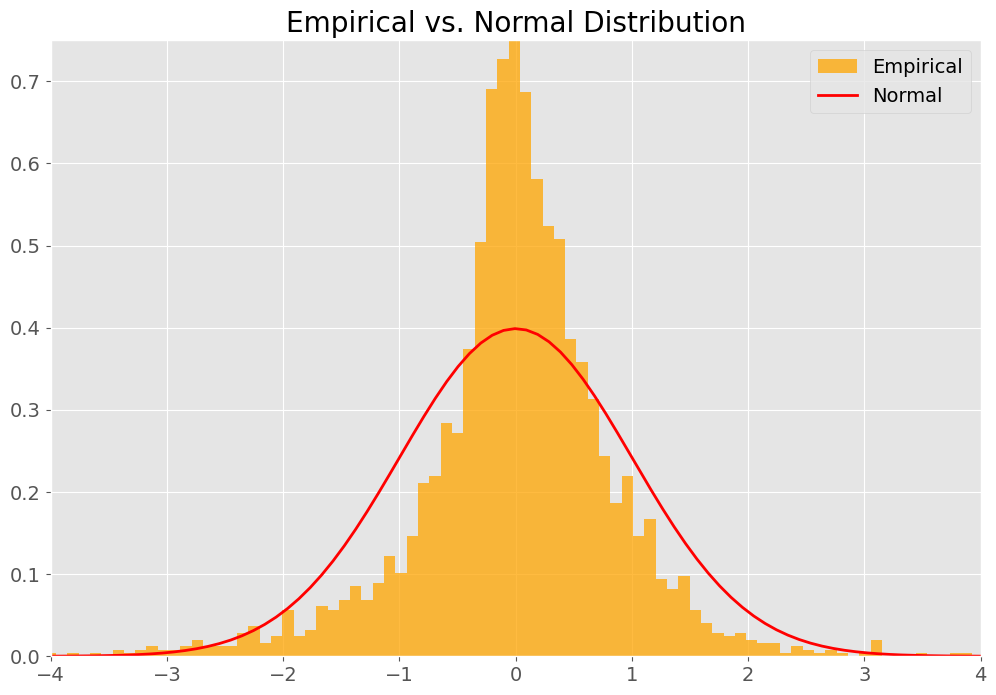

In [10]:
# Define bins
x = np.linspace(df['Scaled_Return'].min(), df['Scaled_Return'].max(), 200)

# Calculate normal probability density function
y = (1/np.sqrt(2*np.pi) * np.exp(-0.5*x**2))

# Plot histogram of scaled returns
plt.hist(df['Scaled_Return'], bins=200, density=True, color='orange', alpha=0.75, label='Empirical')

# Plot norm pdf
plt.plot(x,y,label='Normal', color='red', alpha=1)

# Set x and y axis limits
plt.xlim(-4,4)
plt.ylim(0,0.75)

# Set title
plt.title('Empirical vs. Normal Distribution')

# Set legends
plt.legend()
plt.show()

## 7 References <a id="7-References"></a>

- Numpy Documentation
- Scipy Documentation
- Paul Wilmott (2007), Paul Wilmott introduces Quantitative Finance
- Python Resources